In [ ]:
# ! pip install pandas
# ! pip install matplotlib==3.10.9

# ETL

In [2]:
import pandas as pd
print(pd.__version__)

3.0.2


In [ ]:
# is_fishing quando -1 não tem dados, sera que deve ser usado para treinar o modelo?
# é um ponto onde o barco estava e deslocamento ? 
# existe correlação entre is_fishing e speed ?
# modelo deve levar em consideração multiplos pontos para classificar se o barco esta pescando ou não? 
# modelo deve levar em consideração o tipo de embarcação ?


In [131]:
import pandas as pd 


df_drift = pd.read_csv('data/drifting_longlines.csv')
# df_drift = pd.read_csv('data/fixed_gear.csv')
# df_drift = pd.read_csv('data/pole_and_line.csv')
# df_drift = pd.read_csv('data/purse_seines.csv') 
# df_drift = pd.read_csv('data/trawlers.csv')
# df_drift = pd.read_csv('data/unknown.csv')

df_drift.head()

,mmsi,timestamp,distance_from_shore,distance_from_port,speed,course,lat,lon,is_fishing,source
0,1.263956e+13,1.327137e+09,232994.281250,311748.65625,8.2,230.500000,14.865583,-26.853662,-1.0,dalhousie_longliner
1,1.263956e+13,1.327137e+09,233994.265625,312410.34375,7.3,238.399994,14.863870,-26.856800,-1.0,dalhousie_longliner
2,1.263956e+13,1.327137e+09,233994.265625,312410.34375,6.8,238.899994,14.861551,-26.860649,-1.0,dalhousie_longliner
3,1.263956e+13,1.327143e+09,233994.265625,315417.37500,6.9,251.800003,14.822686,-26.865898,-1.0,dalhousie_longliner
4,1.263956e+13,1.327143e+09,233996.390625,316172.56250,6.1,231.100006,14.821825,-26.867579,-1.0,dalhousie_longliner


In [132]:
df_drift.info()

<class 'pandas.DataFrame'>
RangeIndex: 13968727 entries, 0 to 13968726
Data columns (total 10 columns):
 #   Column               Dtype  
---  ------               -----  
 0   mmsi                 float64
 1   timestamp            float64
 2   distance_from_shore  float64
 3   distance_from_port   float64
 4   speed                float64
 5   course               float64
 6   lat                  float64
 7   lon                  float64
 8   is_fishing           float64
 9   source               str    
dtypes: float64(9), str(1)
memory usage: 1.0 GB


In [133]:
df_drift.columns

Index(['mmsi', 'timestamp', 'distance_from_shore', 'distance_from_port',
       'speed', 'course', 'lat', 'lon', 'is_fishing', 'source'],
      dtype='str')

In [134]:
# show nan por column
df_drift.isna().sum()

mmsi                    0
timestamp               0
distance_from_shore     0
distance_from_port      0
speed                  98
course                 98
lat                     0
lon                     0
is_fishing              0
source                  0
dtype: int64

In [135]:
df_drift['is_fishing'].value_counts()

is_fishing
-1.000000    13748986
 1.000000      138163
 0.000000       79574
 0.666667        1076
 0.333333         809
 0.750000         110
 0.250000           9
Name: count, dtype: int64

In [136]:
df_drift.describe()

,mmsi,timestamp,distance_from_shore,distance_from_port,speed,course,lat,lon,is_fishing
count,1.396873e+07,1.396873e+07,1.396873e+07,1.396873e+07,1.396863e+07,1.396863e+07,1.396873e+07,1.396873e+07,1.396873e+07
mean,1.293850e+14,1.434290e+09,5.845311e+05,7.897505e+05,5.464779e+00,1.814876e+02,-8.997629e+00,3.758693e+00,-9.743015e-01
std,7.887357e+13,3.984275e+07,5.420068e+05,6.915438e+05,4.043567e+00,1.050503e+02,2.439311e+01,1.095971e+02,2.119947e-01
min,5.601266e+12,1.325376e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-7.519017e+01,-1.800000e+02,-1.000000e+00
25%,6.260384e+13,1.410706e+09,1.019092e+05,2.130206e+05,2.100000e+00,9.070000e+01,-2.601550e+01,-8.808668e+01,-1.000000e+00
50%,1.184859e+14,1.447302e+09,4.576393e+05,6.375249e+05,5.500000e+00,1.811000e+02,-1.497954e+01,-1.716495e+00,-1.000000e+00
75%,1.980758e+14,1.466506e+09,9.603664e+05,1.210432e+06,8.500000e+00,2.711000e+02,4.485790e+00,1.009811e+02,-1.000000e+00
max,2.812058e+14,1.480032e+09,4.430996e+06,7.181037e+06,1.023000e+02,5.110000e+02,8.333266e+01,1.799938e+02,1.000000e+00


In [137]:
# Dados parecem estar bem desbalanceados, o que pode ser um problema para treinar um modelo de classificação.
# Dados parecem ter uma boa qualidade, sem valores faltantes, sem valores extremos, e com tipos de dados adequados.

In [138]:
# Remover duplicatas mesmo com source diferente, pois o mesmo ponto pode ter sido classificado por mais de um modelo.
df_drift = df_drift.drop_duplicates(subset=['mmsi', 'timestamp', 'distance_from_shore', 'distance_from_port',
       'speed', 'course', 'lat', 'lon', 'is_fishing'])

# Visualizações/Analise Exploratoria

In [139]:
# agrupar por mmsi contarndo o numero de pontos por embarcação
df_drift.groupby('mmsi').size().sort_values(ascending=False)

mmsi
6.260384e+13    411087
5.641469e+13    353203
3.186568e+13    294401
3.642780e+13    290823
8.791928e+13    285514
                 ...  
1.680158e+14     13289
1.263956e+13     11846
2.774583e+14     11273
3.222535e+13     10522
2.088869e+14      9749
Length: 110, dtype: int64

## Mapa com rota de uma embarcação com pontos coloridos de acordo com o is_fishing

In [140]:
# agrupar por mmsi
# Separar 1 embarcação
# agrupar por rotas, organizando por timestamp
# rotas começão e terminao em 0 de distancia em distance_from_shore e distance_from_port

gb = df_drift.groupby('mmsi')
# pegar maior grupo
largest_group = gb.size().idxmax()
largest_group_df = gb.get_group(largest_group)
largest_group_df = largest_group_df.sort_values('timestamp')



In [141]:
largest_group_df[(largest_group_df["distance_from_shore"]<1.0) & (largest_group_df["speed"]==0.0)].sort_values('distance_from_port')

,mmsi,timestamp,distance_from_shore,distance_from_port,speed,course,lat,lon,is_fishing,source
5504600,6.260384e+13,1.367005e+09,0.0,999.975464,0.0,119.400002,-17.537039,-149.569931,-1.0,crowd_sourced
5504601,6.260384e+13,1.367005e+09,0.0,999.975464,0.0,186.199997,-17.537033,-149.569916,-1.0,crowd_sourced
5504602,6.260384e+13,1.367005e+09,0.0,999.975464,0.0,25.400000,-17.537029,-149.569916,-1.0,crowd_sourced
5504603,6.260384e+13,1.367006e+09,0.0,999.975464,0.0,304.399994,-17.537079,-149.569931,-1.0,crowd_sourced
5504605,6.260384e+13,1.367007e+09,0.0,999.975464,0.0,118.099998,-17.537016,-149.569931,-1.0,crowd_sourced
...,...,...,...,...,...,...,...,...,...,...
5817351,6.260384e+13,1.467938e+09,0.0,1414.178833,0.0,22.100000,-17.533749,-149.572327,-1.0,crowd_sourced
5817352,6.260384e+13,1.467939e+09,0.0,1414.178833,0.0,226.100006,-17.533741,-149.572327,-1.0,crowd_sourced
5817353,6.260384e+13,1.467939e+09,0.0,1414.178833,0.0,215.199997,-17.533739,-149.572327,-1.0,crowd_sourced
5817354,6.260384e+13,1.467939e+09,0.0,1414.178833,0.0,224.000000,-17.533728,-149.572327,-1.0,crowd_sourced


In [142]:
largest_group_df.sort_values('timestamp')
# timestamp to datetime
largest_group_df['timestamp'] = pd.to_datetime(largest_group_df['timestamp'], unit='s')

In [143]:
largest_group_df

,mmsi,timestamp,distance_from_shore,distance_from_port,speed,course,lat,lon,is_fishing,source
5498014,6.260384e+13,2012-11-22 21:07:41,999.975464,9.999755e+02,0.0,258.600006,-17.532776,-149.580154,-1.0,crowd_sourced
5498015,6.260384e+13,2012-11-22 21:14:09,999.975464,9.999755e+02,0.0,127.000000,-17.532780,-149.580154,-1.0,crowd_sourced
5498016,6.260384e+13,2012-11-22 21:16:29,999.975464,9.999755e+02,0.1,216.899994,-17.532784,-149.580154,-1.0,crowd_sourced
5498017,6.260384e+13,2012-11-22 21:16:48,999.975464,9.999755e+02,0.0,137.500000,-17.532782,-149.580154,-1.0,crowd_sourced
5498018,6.260384e+13,2012-11-22 21:17:29,999.975464,9.999755e+02,0.1,26.299999,-17.532780,-149.580154,-1.0,crowd_sourced
...,...,...,...,...,...,...,...,...,...,...
5909096,6.260384e+13,2016-11-24 21:59:02,474443.843750,1.071175e+06,5.8,118.000000,-26.493069,-152.100540,-1.0,crowd_sourced
5909097,6.260384e+13,2016-11-24 22:25:13,476795.406250,1.075978e+06,1.7,199.300003,-26.517015,-152.073059,-1.0,crowd_sourced
5909098,6.260384e+13,2016-11-24 22:50:12,478616.500000,1.078584e+06,0.7,205.199997,-26.548256,-152.054367,-1.0,crowd_sourced
5909099,6.260384e+13,2016-11-24 23:16:56,480676.250000,1.082595e+06,7.5,148.699997,-26.574720,-152.040039,-1.0,crowd_sourced


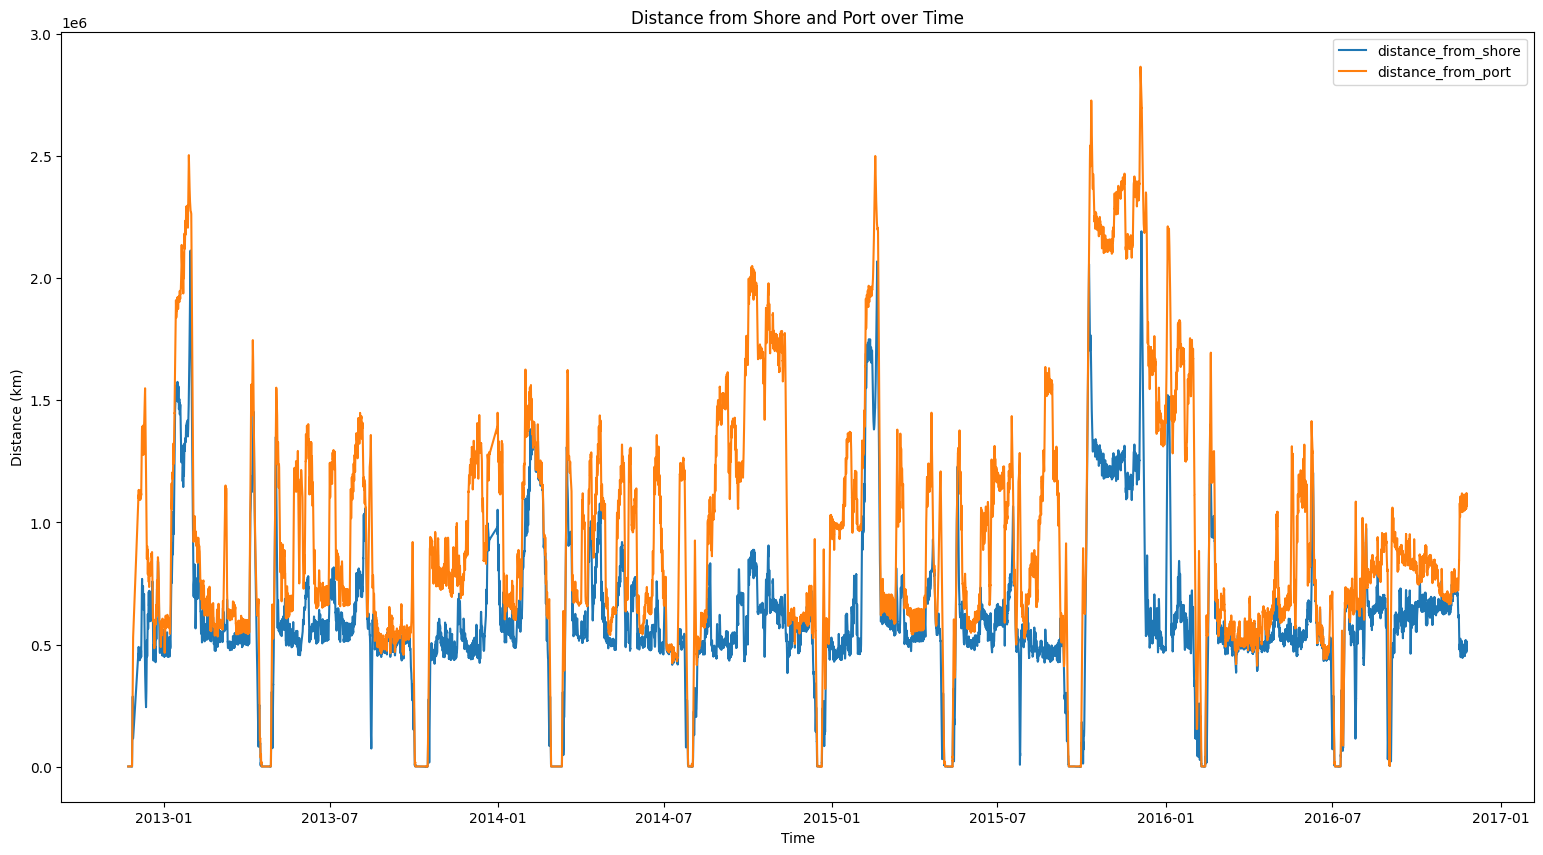

In [144]:
# plot distance_from_shore and distance_from_port over time

import matplotlib.pyplot as plt
plt.figure(figsize=(19, 10))
plt.plot(largest_group_df['timestamp'], largest_group_df['distance_from_shore'], label
='distance_from_shore')
plt.plot(largest_group_df['timestamp'], largest_group_df['distance_from_port'], label='distance_from_port')
plt.legend()
plt.title('Distance from Shore and Port over Time')
plt.xlabel('Time')
plt.ylabel('Distance (km)')
plt.show()

In [145]:
# quando ha aproximação da costa e de um porto o barco pode esta começando ou encerrando uma rota de pesca.


In [146]:
rotas = []
current_route = []
for i in range(len(largest_group_df)):
    row = largest_group_df.iloc[i]
    if row['distance_from_shore'] == 0 and row['speed'] == 0:
        if current_route:
            rotas.append(current_route)
            current_route = []
    else:
        current_route.append(row)
if current_route:
    rotas.append(current_route)
    current_route = []
    


In [147]:
# show rota 1
rota_1 = rotas[0]
rota_1_df = pd.DataFrame(rota_1)
rota_1_df.head()

,mmsi,timestamp,distance_from_shore,distance_from_port,speed,course,lat,lon,is_fishing,source
5498014,6.260384e+13,2012-11-22 21:07:41,999.975464,999.975464,0.0,258.600006,-17.532776,-149.580154,-1.0,crowd_sourced
5498015,6.260384e+13,2012-11-22 21:14:09,999.975464,999.975464,0.0,127.000000,-17.532780,-149.580154,-1.0,crowd_sourced
5498016,6.260384e+13,2012-11-22 21:16:29,999.975464,999.975464,0.1,216.899994,-17.532784,-149.580154,-1.0,crowd_sourced
5498017,6.260384e+13,2012-11-22 21:16:48,999.975464,999.975464,0.0,137.500000,-17.532782,-149.580154,-1.0,crowd_sourced
5498018,6.260384e+13,2012-11-22 21:17:29,999.975464,999.975464,0.1,26.299999,-17.532780,-149.580154,-1.0,crowd_sourced


# HeatMap de Correlação entre colunas